In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [6]:
df = pd.read_csv(r'car_ownership.csv', delimiter=',')
df.head()

,monthly_salary,owns_car
0,22000,0
1,25000,0
2,47000,1
3,52000,0
4,46000,1


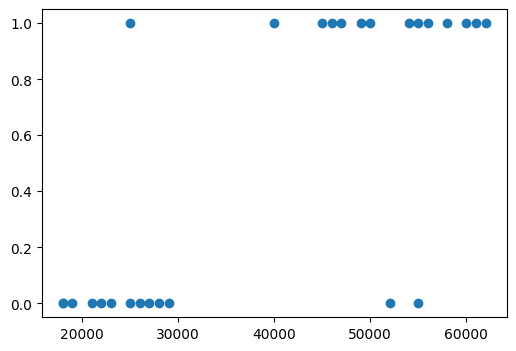

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(df['monthly_salary'], df['owns_car'])
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
model = LogisticRegression()
X_train, X_test, y_train, y_test = train_test_split(df[['monthly_salary']], df['owns_car'], test_size=0.2, random_state=21)
model.fit(X_train, y_train)

LogisticRegression()

In [18]:
y_pred = model.predict(X_test)

In [21]:
print(y_test.tolist())
print(y_pred)

[1, 1, 0, 0, 1, 0, 1]
[1 1 0 0 1 1 1]


In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred), 6/7

(0.8571428571428571, 0.8571428571428571)

In [35]:
y_pred_prob = model.predict_proba(X_test)[:,1]
thresshold = 0.7
y_pred_custom_thresshold = (y_pred_prob >= thresshold).astype(int)
y_pred_custom_thresshold

array([0, 1, 0, 0, 1, 1, 1])

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for t in [0.3, 0.5, 0.7]:
    y_pred_t = (y_pred_prob >= t).astype(int)
    print(f"Threshold: {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred_t))
    print("Precision:", precision_score(y_test, y_pred_t))
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1:", f1_score(y_test, y_pred_t))
    print("-" * 30)


Threshold: 0.3
Accuracy: 0.8571428571428571
Precision: 0.8
Recall: 1.0
F1: 0.8888888888888888
------------------------------
Threshold: 0.5
Accuracy: 0.8571428571428571
Precision: 0.8
Recall: 1.0
F1: 0.8888888888888888
------------------------------
Threshold: 0.7
Accuracy: 0.7142857142857143
Precision: 0.75
Recall: 0.75
F1: 0.75
------------------------------


In [36]:
model.coef_, model.intercept_

(array([[0.00015527]]), array([-5.82325991]))

In [43]:
import math
def sigmoid(x):
    return 1/(1+ math.exp(-x))

def prediction_function(model, salary): 
    z = model.coef_*salary + model.intercept_
    print(z)
    type(z)
    y = sigmoid(z[0][0])
    return y

In [45]:
prediction_function(model, 29000)

[[-1.32051202]]


0.21073311877737802

### Multiclass Logistic Regression

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [13]:
df['target_names'] = df['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})
df.columns = df.columns.str.replace(' ', '_')
df.sample(5)

,sepal_length_(cm),sepal_width_(cm),petal_length_(cm),petal_width_(cm),target,target_names
144,6.7,3.3,5.7,2.5,2,virginica
3,4.6,3.1,1.5,0.2,0,setosa
51,6.4,3.2,4.5,1.5,1,versicolor
83,6.0,2.7,5.1,1.6,1,versicolor
111,6.4,2.7,5.3,1.9,2,virginica


<Axes: xlabel='sepal_length_(cm)', ylabel='sepal_width_(cm)'>

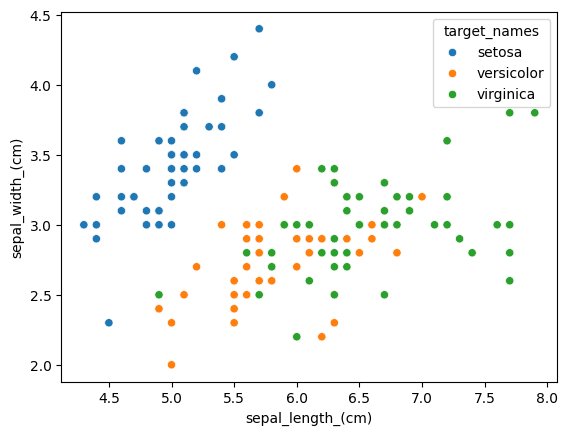

In [14]:
sns.scatterplot(df, x = 'sepal_length_(cm)', y = 'sepal_width_(cm)', hue='target_names')

<Axes: xlabel='petal_length_(cm)', ylabel='petal_width_(cm)'>

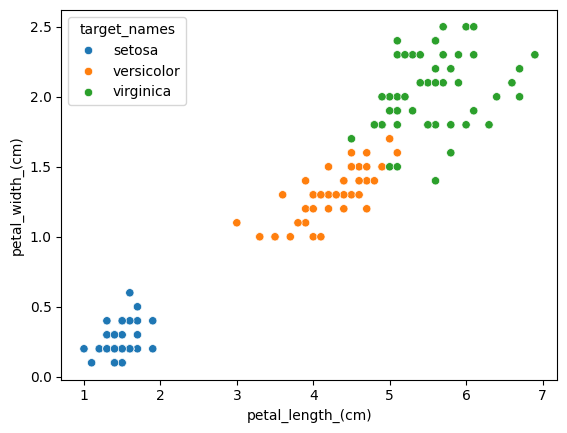

In [15]:
sns.scatterplot(df, x = 'petal_length_(cm)', y = 'petal_width_(cm)', hue='target_names')

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x = df[['sepal_length_(cm)', 'sepal_width_(cm)', 'petal_length_(cm)', 'petal_width_(cm)']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=21)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)


LogisticRegression(max_iter=200)

In [19]:
model.score(X_test, y_test)

0.9333333333333333

In [24]:
y_pred = model.predict(X_test).tolist()
y_pred[:10], y_test[:10].tolist()

([1, 0, 0, 0, 1, 1, 0, 2, 0, 0], [1, 0, 0, 0, 1, 1, 0, 2, 0, 0])

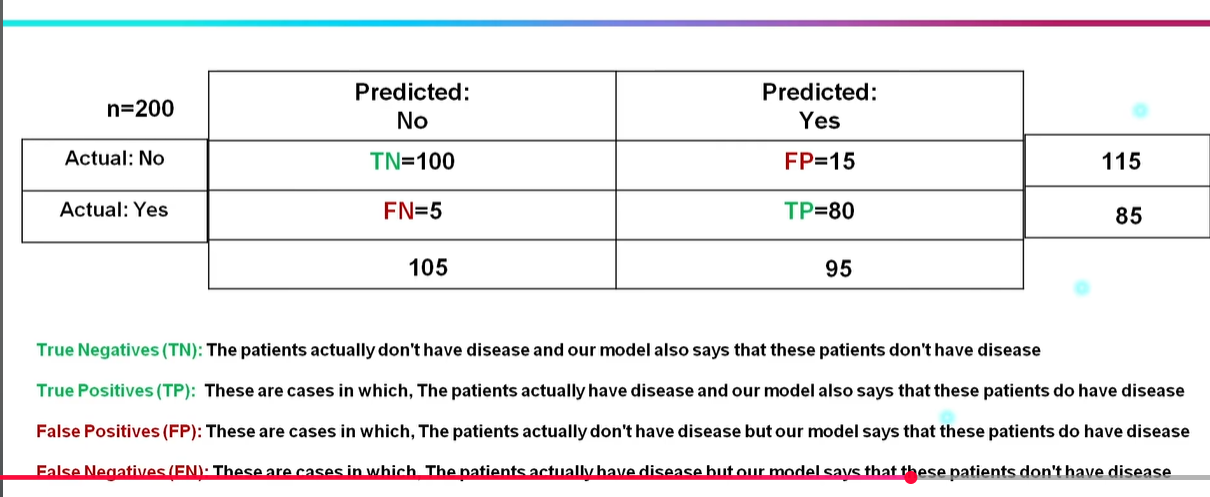

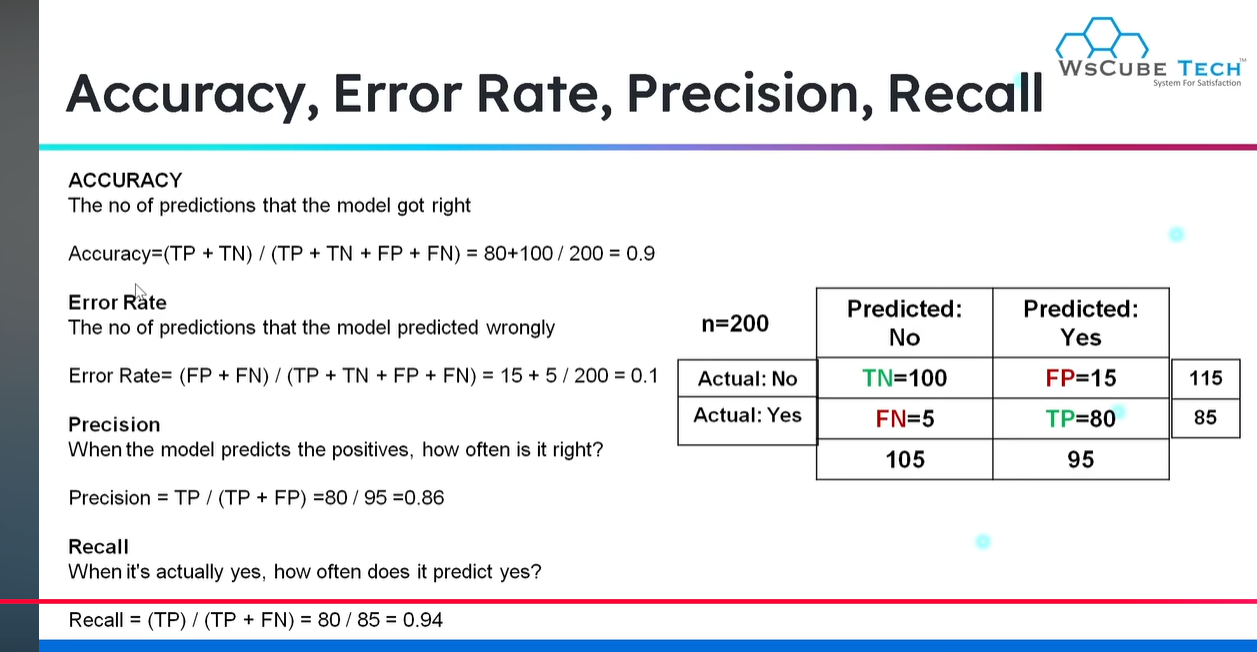

In [29]:
from sklearn.metrics import confusion_matrix
data = confusion_matrix(y_test, y_pred)

In [38]:
y_test[y_test==0].sum()

np.int64(0)

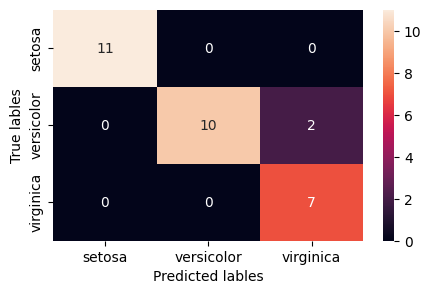

In [35]:
plt.figure(figsize=(5,3))
sns.heatmap(data, annot=True, xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted lables')
plt.ylabel('True lables')
plt.show()

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.83      0.91        12
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.95      0.93      0.93        30



| Option       | Meaning                                                   | Use When                              |
| ------------ | --------------------------------------------------------- | ------------------------------------- |
| `'micro'`    | Global count of TP, FP, FN (all classes combined)         | Jab overall performance chahiye       |
| `'macro'`    | Average of F1 of all classes (equal weight to each class) | Jab har class equally important hai   |
| `'weighted'` | Average of F1 weighted by number of samples per class     | Jab dataset **imbalanced** hai        |
| `None`       | Returns F1 for **each class separately**                  | Jab har class ka alag score dekhna ho |


In [43]:
from sklearn.metrics import f1_score
from sklearn.metrics import f1_score
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average=None)

print("Micro F1:", f1_micro)
print("Macro F1:", f1_macro)
print("Weighted F1:", f1_weighted)


Micro F1: 0.9333333333333333
Macro F1: 0.9280303030303031
Weighted F1: [1.         0.90909091 0.875     ]
